# Аналитическое исследование тенденций в индустрии компьютерных игр

**Цель исследования:** 

Необходимо выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании. Для достижения цели из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы. Данные предоставлены до 2016 года (за 2016-й год данные не полные). Прогноз необходимо сделать на 2017 год.

**Задачи исследования:**

1) Необходимо изучить общую информацию о ретроспективных данных проанализировать для дальнейшей подготовки.

2) Провести предобработку данных: изменение наименования столбцов, обработка пропусков данных, удаление дубликатов и изменение типов данных столбцов. Также может понадобится создание дополнительных столбцов в датафрейме.

3) Провести исследовательский анализ данных в части фильтрации информации на актуальность и применимость для целей исследования, определить наиболее популярные платформы, влияние жанров и оценок игр на итоговые продажи.

4) Определения лидеров жанров и платформ в разрезе по регионам продаж. Оценить влияние и отличия. Выявить влияние рейтинга игр на продажи.

5) Проверка ряда гипотез.

6) Сделать итоговый вывод.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from math import factorial
from math import sqrt
from scipy.stats import binom

### Загрузка данных и изучение общей информации

In [2]:
df = pd.read_csv('/datasets/games.csv') #читаем файл csv
display(df.head()) #выводим первые 5 строк

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
df.info() #выводим общую информацию о датафрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


**Вывод:** 

В представленном датафремейме 11 столбцов и 16715 строк. Пропуски данных обнаружены в 6 столбцах: название, год релиза, жанр, оценка критиков, оценка пользователей и рейтинг. Также в некоторых столбцах выявлены некорректные типы данных. 


### Предобработка данных

#### Переименование столбцов

In [4]:
df = df.rename(columns = {'Name': str.lower('Name'),
                          'Platform': str.lower('Platform'),
                          'Year_of_Release': str.lower('Year_of_Release'),
                          'Genre': str.lower('Genre'),
                          'NA_sales': str.lower('NA_sales'),
                          'EU_sales': str.lower('EU_sales'),
                          'JP_sales': str.lower('JP_sales'),
                          'Other_sales': str.lower('Other_sales'),
                          'Critic_Score': str.lower('Critic_Score'),
                          'User_Score': str.lower('User_Score'),
                          'Rating': str.lower('Rating')
})# приводим столбцы к нижнему регистру

In [5]:
df.columns #проверяем результат

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

Все названия столбцов в нижнем регистре, пробелов нет.

#### Обработка пропусков

Как выяснили ранее пропуски данных обнаружены в 6 столбцах: название, год выхода, жанр, оценка критиков, оценка пользователей и рейтинг. Встречаются как незначительное количество пропусков, например в столбце "год выхода" около 260 пропусков, так и значительные: в столбце "оценка критиков" отсутствует половина данных. Для начала удалим пропуски в столбцах где незначительное количество пропусков.

##### Удаление строк с пропусками в столбцах "название", "год выхода", "жанр". 
Для этих строк логически заполнить данные затруднительно, а на объем данных повлияет не сильно. 

In [6]:
df = df.dropna(subset = ['name'])
df['name'].isna().sum()

0

In [7]:
df = df.dropna(subset = ['year_of_release'])
df['year_of_release'].isna().sum()

0

In [8]:
df = df.dropna(subset = ['genre'])
df['genre'].isna().sum()

0

In [9]:
df.info()#проверяем оставшийся датафрейм на размерность

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


##### Обработка пропусков в столбцах "оценка критиков", "оценка пользователей", "рейтинг". 

Далее необходимо разобраться со столбцами, в которые отсутствует значительная часть данных. Из их названия видно, что все они касаются оценок и возрастного ценза. После поверхностно просмотра датафрейма можно сделать вывод, что пропуски во всех трех столбцах соответствуют старым играм. В те времена еще не было рейтингов и возрастных порогов. Проверим это утверждение.

In [10]:
df.isnull().any(axis = 1).sum()#ищем количество строк с пропусками хотя бы в 1 строке

8566

Всего в датафрейме 16444 строк. Объединение числа строк с хотя бы одним пропуском равно 8566. Ищем количество строк, где пропуски отсутствуют: 16444 - 8566 = 7878 строк, что приблизительно соответствует числу заполненных строк в столбце "оценка критиков", где больше всего пропусков - 7983. Предположение подтвердилось: пропуски в трех столбцах со значительными потерями данных относятся к одним и тем же строкам. Рассмотрим эти строки.

In [11]:
df_null = df[df.isna().values.any(axis=1)]#создаем датафрейм, где есть хотя бы один пропуск в данных
display(df_null.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN


Попробуем провести анализ зависимости рейтинга игр от организации ESRB на возможные зависимости от других столбцов таблицы. Логично предположить, что продажи, оценки критиков/пользователей и год выпуска не могут влиять на рейтинг игр. Гипотетически жанр игр и платформы выхода могут быть как-то привязаны к рейтингу. Проверим предположение.

In [12]:
df['rating'].value_counts()#проверяем число уникальных значений рейтинга

E       3921
T       2905
M       1536
E10+    1393
EC         8
K-A        3
AO         1
RP         1
Name: rating, dtype: int64

Выявлено 4 самых частовстречающихся значения рейтинга игр. Проверим зависимость двух из них (E, T) от жанра игр и платформы.

In [13]:
df_e = df.query('rating == "E"')#создаем срез основной таблицы только с рейтингом Е
print(df_e['genre'].value_counts().head())
df_e['platform'].value_counts().head()

Sports      1162
Racing       576
Misc         449
Action       410
Platform     354
Name: genre, dtype: int64


DS      865
PS2     541
Wii     493
GBA     419
X360    243
Name: platform, dtype: int64

In [14]:
df_t = df.query('rating == "T"')#создаем срез основной таблицы только с рейтингом T
print(df_t['genre'].value_counts().head())
df_t['platform'].value_counts().head()

Action          670
Role-Playing    415
Fighting        357
Shooter         340
Misc            228
Name: genre, dtype: int64


PS2     567
X360    334
PS3     329
PC      293
XB      285
Name: platform, dtype: int64

Предположение не подтвердилось: из полученных данных выше невозможно однозначно сделать вывод о том, что для конкрентного типа рейтинга характерны какие-то конкретные жанры или платформы. Да, есть отличия, но есть и пересечения: жанр "Action" часто встречается в обоих случаях, а выходили игры этих рейтингов на "PS2" и "X360". Провести логическое заполнение пропусков в столбце Рейтинга невозможно, т.к. отсутствуют очевидные зависимости от других столбцов. Заполним их значением "Unknown".

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


In [16]:
df['rating'] = df['rating'].fillna('Unknown')# заполняем пустые значения

Теперь необходимо разобраться со столбцами "оценка критиков" и "оценка пользователей". Заполнять данные в этих столбцах некорректно. Просто изменим тип данных столбца "оценка пользователей" на корректный, т.е. float.

In [17]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='ignore')
df['user_score'] = df['user_score'].astype('float', errors='ignore')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           16444 non-null  object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


Тип данных не изменился. Скорее всего в значения попали нечисловые значения. Выясним это рассмотрев все уникальные значения столбца.

In [19]:
print(df['user_score'].unique())
df['user_score'].value_counts()

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']


tbd    2376
7.8     322
8       285
8.2     276
8.3     252
       ... 
0.2       2
1         2
9.6       2
9.7       1
0         1
Name: user_score, Length: 96, dtype: int64

Среди числовых значений есть пустые "nan", о которых уже известно, а также значения "tbd". которое достаточно часто встревается - 2376 раз. Этим понятием обозначают показатели, которые еще не определены ("to be determined"). Получается, что это тоже пустые значение. Удалим значения "tbd".

In [20]:
df.replace('tbd', np.nan, inplace=True)#заменяем значения tbd пустыми значениями
df['user_score'].value_counts()#проверяем результат

7.8    322
8      285
8.2    276
8.3    252
7.5    249
      ... 
0.2      2
1        2
9.6      2
9.7      1
0        1
Name: user_score, Length: 95, dtype: int64

Теперь изменить тип данных столбца "оценка пользователей" на тип данных float.

In [21]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')#меняем тип данных на float

In [22]:
df.info()# проверяем результат

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


**Промежуточный вывод по результатам заполнения данных:**
1) Строки, где в столбцах ("название", "год выхода", "жанр") встречались пропуски удалили. На размерность датафрейма пости не повлияло.

2) Пропуски в столбце "рейтинг" логически не заполнить. Заменили пустые значения на "unknown".

3) Заполнять данные в столбцах оценок пользователей и критиков некорректно. Изменили тип данных столбца "оценка пользователей" на float.

4) Выявлено строковой значение "tbd" в оценках пользовалелей, что расшифровывается как "to be determined". Значения приравнены к пустым и удалены.

5) Причины возниковения пропусков: малочисленные пропуски в столбцах  - скорее всего просто данные в исходном источнике отсутствовали. Более чем в половине данных отсутствовали значения в столбцах  "оценка критиков", "оценка пользователей", "рейтинг" и это были одни и те же строки. Выявить закономерность возникновения ошибок по году выхода и платформене не получилось. Вероятно, что это ошибка выгрузки данных. Необходимо отправить отчет об ошибке в соответствующий отдел.

##### Добавление столбца с суммарными продажами

Функция "total", которая считает сумму продаж определена ранее, но применялась к срезу таблицы, а не к общему датафрейму. Применим ее к датафрейму.

In [23]:
def total(row):  #добавляем столбец с суммарными продажами
    return row['na_sales'] + row['eu_sales'] + row['jp_sales'] + row['other_sales']
df['total_sales'] = df.apply(total, axis=1).copy()
display(df.head())#проверяем результат

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,Unknown,31.38


**Вывод:**
Столбец с суммарными продажами добавили. Он пригодится в дальнейшем исследовании. 

##### Изменение типов данных

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
 11  total_sales      16444 non-null  float64
dtypes: float64(8), object(4)
memory usage: 1.6+ MB


Необходимо иземнить тип данных столбца "год выпуска": текущий - с плавающей точкой, исправить на целочисленный. Тип данных столбца "оценка пользователей" был исправлен ранее. Остальные столбцы в корректировке не нуждаются.

In [25]:
df['year_of_release'] = df['year_of_release'].astype('int', errors='ignore')
#меняем тип данных столбца год выхода на целочисленный

In [26]:
df.info()# проверяем результат

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
 11  total_sales      16444 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.6+ MB


**Вывод:** типы данных приведены к корректным.

##### Проверка явных дубликатов

In [27]:
df.duplicated().sum()

0

Явные дубликаты не выявлены.

In [28]:
df[df[['name', 'platform','year_of_release']].duplicated(keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E,2.56
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E,0.01


Выявлена одна строка-дубликат. Удалим ее.

In [29]:
df.drop(index=16230, inplace=True)

**Общий вывод по результатам предобработки данных:** 
1) Все названия столбцов переведены в нижний регистр, пробелов нет.

2) Удалены строки с пропусками в столбцах "название", "год выхода", "жанр". На размерность датафрейма пости не повлияло.

3) Пропуски в столбце "рейтинг" логически не заполнить. Заменили пустые значения на "unknown".

4) Заполнять данные в столбцах оценок пользователей и критиков некорректно. Изменили тип данных столбца "оценка пользователей" на float.

5) Выявлено строковой значение "tbd" в оценках пользовалелей, что расшифровывается как "to be determined". Значения приравнены к пустым и удалены.

6) Причины возниковения пропусков: малочисленные пропуски в столбцах  - скорее всего просто данные в исходном источнике отсутствовали. Более чем в половине данных отсутствовали значения в столбцах  "оценка критиков", "оценка пользователей", "рейтинг" и это были одни и те же строки. Выявить закономерность возникновения ошибок по году выхода и платформене не получилось. Вероятно, что это ошибка выгрузки данных. Необходимо отправить отчет об ошибке в соответствующий отдел.

7) Проведена проверка на дубликаты. Удалена 1 строка-дубликат.

### Исследовательский анализ данных

#### Анализ распределения количества выпущенных игр по годам

Рассмотрим количество игр, которые выпускались в разные годы.

In [30]:
df_group_year = df.groupby('year_of_release').agg(name = ('name', 'count')).reset_index()#делаем группировку
df_group_year = df_group_year.rename(columns={'name':'count'}) #переименовываем столбец

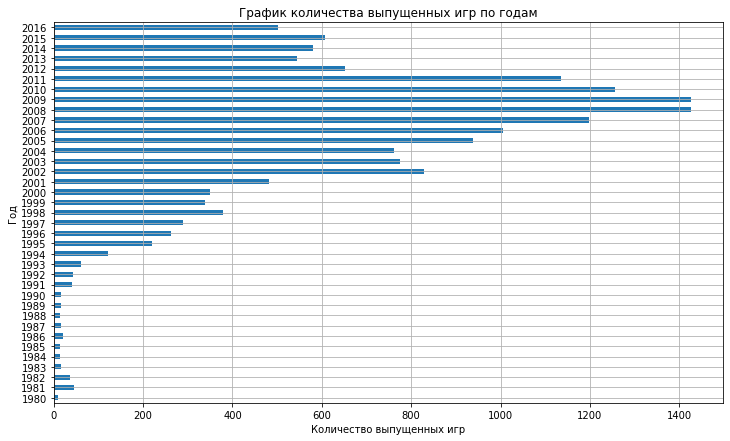

In [31]:
# Построение горизонтальной диаграммы
ax = df_group_year.plot(
    x='year_of_release',
    y='count',
    grid = True,
    kind='barh',
    legend=False,
    figsize=(12, 7),
    title='График количества выпущенных игр по годам'
)
# Добавление меток осей
plt.xlabel('Количество выпущенных игр')
plt.ylabel('Год')

# Отображение графика
plt.show()

**Вывод:**
До 1995 года выходило менее 200 игр в год. Дальше наблюдается резкий рост. Пиковое значение наблюдается в 2008 и 2009 годах. Далее идет такое же резкое снижение до 500 игр в год в 2016 году. Для целей настоящего исследования не все данные будут актуальны. Для анализа популярности и прибыльности платформ/жанров не все данные будут нужны, а некоторые могут и смазать результаты. С точки зрения количества выпускаемых игр примем в качестве актуальных данных диапазон 2001 - 2016 года, где выпускалось более 500 игр/год. 

#### Анализ распределения суммы продаж по платформам

In [32]:
df_group_platform = df.groupby('platform').agg(name = ('total_sales', 'sum')).reset_index().sort_values(by='name')
#делаем группировку
df_group_platform = df_group_platform.rename(columns={'name':'total_sales'}) #переименовываем столбец

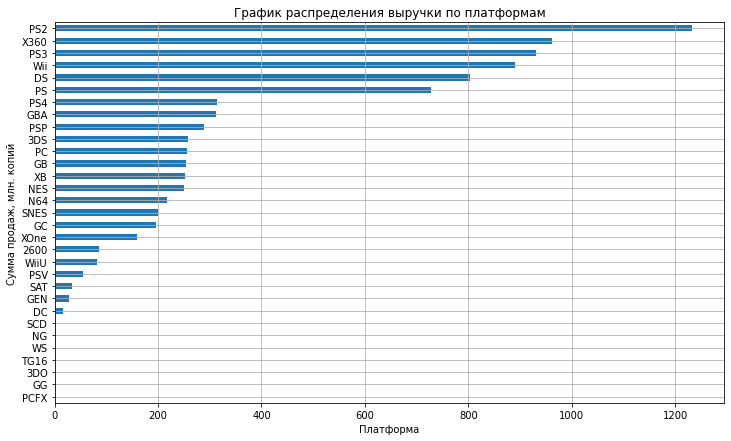

In [33]:
# Построение горизонтальной диаграммы
ax = df_group_platform.plot(
    x='platform',
    y='total_sales',
    grid = True,
    kind='barh',
    legend=False,
    figsize=(12, 7),
    title='График распределения выручки по платформам'
)
# Добавление меток осей
plt.xlabel('Платформа')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Наибольшее число продаж игр за все годы приходится на 6 платформ: PS2, X360, PS3, Wii, DS и PS. Рассмотрим продажи по этим платформам по годам.

In [34]:
df_platform = df.query('platform == ["PS2", "X360", "PS3", "Wii", "DS", "PS"]')
df_grouped = df_platform.groupby(
    ['platform', 'year_of_release']).agg(
    total_sales = ('total_sales', 'sum')).reset_index()
df_grouped_PS2 = df_grouped.query('platform == "PS2"').sort_values(by='year_of_release')
df_grouped_X360 = df_grouped.query('platform == "X360"').sort_values(by='year_of_release')
df_grouped_PS3 = df_grouped.query('platform == "PS3"').sort_values(by='year_of_release')
df_grouped_Wii = df_grouped.query('platform == "Wii"').sort_values(by='year_of_release')
df_grouped_DS = df_grouped.query('platform == "DS"').sort_values(by='year_of_release')
df_grouped_PS = df_grouped.query('platform == "PS"').sort_values(by='year_of_release')

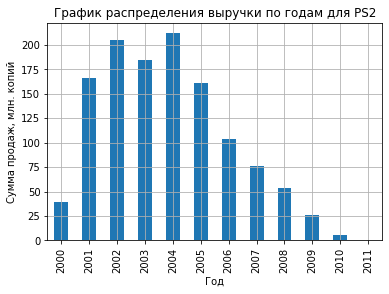

In [35]:
df_grouped_PS2.plot(
    x='year_of_release',
    y='total_sales',
    grid = True,
    kind='bar',
    legend=False,
    title='График распределения выручки по годам для PS2'
)
# Добавление меток осей
plt.xlabel('Год')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Временной диапазон продажи игр для платформы PS2 - 11 лет.

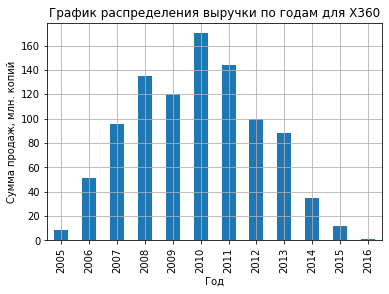

In [36]:
df_grouped_X360.plot(
    x='year_of_release',
    y='total_sales',
    grid = True,
    legend=False,
    kind='bar',
    title='График распределения выручки по годам для X360'
)
# Добавление меток осей
plt.xlabel('Год')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Временной диапазон продажи игр для платформы Х360 - 11 лет.

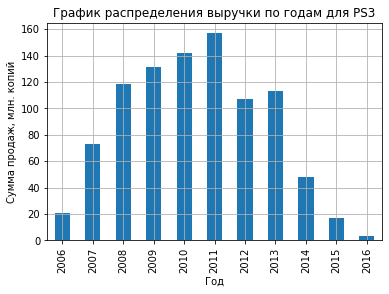

In [37]:
df_grouped_PS3.plot(
    x='year_of_release',
    y='total_sales',
    grid = True,
    legend=False,
    kind='bar',
    title='График распределения выручки по годам для PS3'
)
# Добавление меток осей
plt.xlabel('Год')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Временной диапазон продажи игр для платформы PS3 - 10 лет.

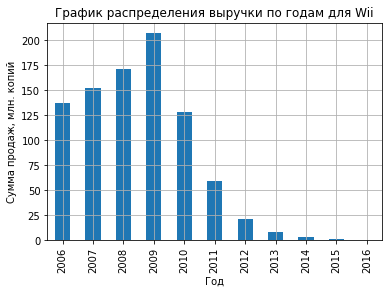

In [38]:
df_grouped_Wii.plot(
    x='year_of_release',
    y='total_sales',
    grid = True,
    legend=False,
    kind='bar',
    title='График распределения выручки по годам для Wii'
)
# Добавление меток осей
plt.xlabel('Год')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Временной диапазон продажи игр для платформы Wii - 10 лет.

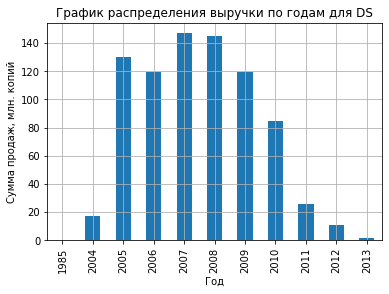

In [39]:
df_grouped_DS.plot(
    x='year_of_release',
    y='total_sales',
    grid = True,
    legend=False,
    kind='bar',
    title='График распределения выручки по годам для DS'
)
# Добавление меток осей
plt.xlabel('Год')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Временной диапазон продажи игр для платформы DS - 9 лет. Аномальное значение продаж в 1985 году в расче не берем.  

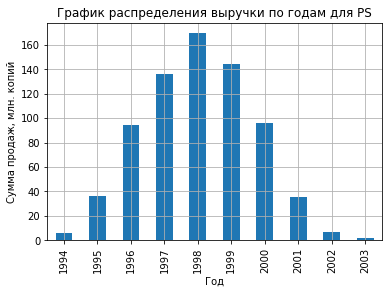

In [40]:
df_grouped_PS.plot(
    x='year_of_release',
    y='total_sales',
    grid = True,
    legend=False,
    kind='bar',
    title='График распределения выручки по годам для PS'
)
# Добавление меток осей
plt.xlabel('Год')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Временной диапазон продажи игр для платформы PS - 9 лет.

In [41]:
PS2_life = df_grouped_PS2['year_of_release'].max() - df_grouped_PS2['year_of_release'].min()
print(f'Жизненный срок платформы PS2 - {PS2_life} лет')
X360_life = df_grouped_X360 ['year_of_release'].max() - df_grouped_X360['year_of_release'].min()
print(f'Жизненный срок платформы X360 - {X360_life} лет')
PS3_life = df_grouped_PS3 ['year_of_release'].max() - df_grouped_PS3['year_of_release'].min()
print(f'Жизненный срок платформы PS3 - {PS3_life} лет')
Wii_life = df_grouped_Wii ['year_of_release'].max() - df_grouped_Wii['year_of_release'].min()
print(f'Жизненный срок платформы Wii - {Wii_life} лет')
DS_life = df_grouped_DS ['year_of_release'].max() - df_grouped_DS.query('year_of_release != 1985')['year_of_release'].min()
print(f'Жизненный срок платформы DS - {DS_life} лет')
PS_life = df_grouped_PS ['year_of_release'].max() - df_grouped_PS['year_of_release'].min()
print(f'Жизненный срок платформы PS - {PS_life} лет')

Жизненный срок платформы PS2 - 11 лет
Жизненный срок платформы X360 - 11 лет
Жизненный срок платформы PS3 - 10 лет
Жизненный срок платформы Wii - 10 лет
Жизненный срок платформы DS - 9 лет
Жизненный срок платформы PS - 9 лет


**Вывод:** среди шести самых популярных платформ построили графики по продажам по годам. Из графиков видно что игры продавались для каждой отдельной платформы в среднем в диапазоне 9-11 лет. Информация полезна с точки зрения определения актуального периода для дальнейшего анализа - определим его в рамере половины среднего срока жизни платформы. Цифры по продажам устаревающих платформ не помогут в построении прогноза. Прогноз необходимо сделать на 2017 год, соотверственно актуальным временным диапазоном можно считать с 2012-2016 годы (четыре полных года и неполный 2016-й).

#### Анализ продаж по платформам за актуальный период

In [42]:
data = df.query('year_of_release >= 2012').copy() #создадим датафрейм только за актуальный период

In [43]:
data_group = data.groupby('platform').agg(name = ('total_sales', 'sum')).reset_index().sort_values(by='name')
#делаем группировку и сортировку
data_group = data_group.rename(columns={'name':'total_sales'}) #переименовываем столбец

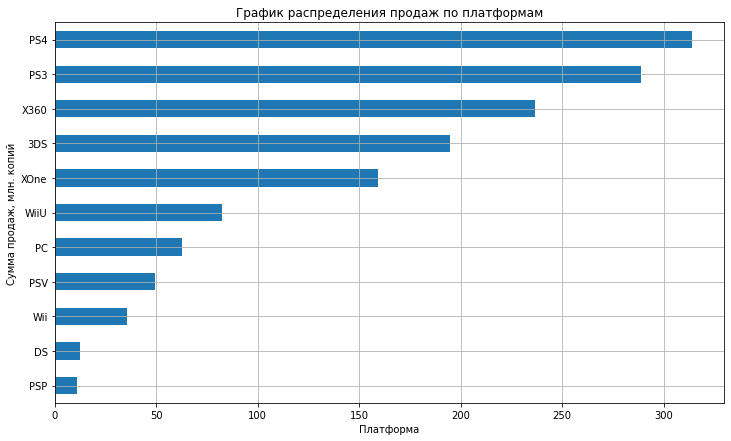

In [44]:
# Построение горизонтальной диаграммы
ax = data_group.plot(
    x='platform',
    y='total_sales',
    grid = True,
    kind='barh',
    legend=False,
    figsize=(12, 7),
    title='График распределения продаж по платформам'
)
# Добавление меток осей
plt.xlabel('Платформа')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Среди платформ с наибольшим количеством продаж игр за период 2012-2016 год выделяются 5: PS3, X360, PS4, 3DS, XOne (свыше 150 млн. копий проданных игр). Рассмотрим все продажи по всем платформам по годам.

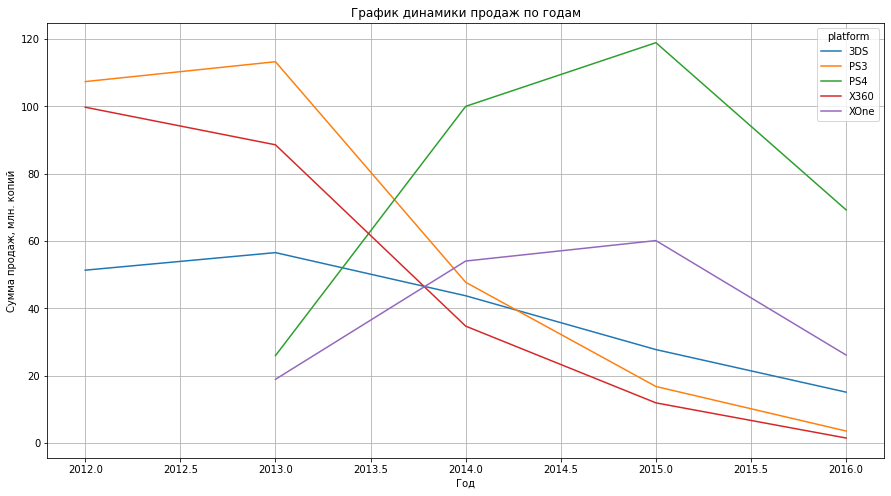

In [45]:
#фильтруем таблицу, группируем и строим график
data.query(
    'platform == ["PS3","X360", "PS4", "3DS", "XOne"]').pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').plot(
    grid=True, figsize=(15, 8), title='График динамики продаж по годам')
# Добавление меток осей
plt.xlabel('Год')
plt.ylabel('Сумма продаж, млн. копий')

# Отображение графика
plt.show()

Из описания предоставленных данных видим, что в таблице не полная информация за 2016 год. Это объясняет почему по всем платформам наблюдается "падение" продаж в этом году. Соответственно если убрать 2016 год из аналитики можно сделать следующие выводы:
1) в абсолютном выражении лидируют три платформы: PS4, XOne и 3DS. Однако PS4 и XOne с 2013 по 2015 года показывают резкий рост продаж и выглядят очень перспективными. В это же время 3DS начиная со своего максимального значения в 2012 году планомерно теряет позиции и прогноз по этой платформе выглядит не так оптимистично как  PS4 и XOne.

2) Платформы PS3 и X360 были абслолютными лидерами в 2012 году, но продажи резко снижались и к концу 2016 года близки к нулю. Самое резкое падение можно наблюдать в 2013 году, как раз когда вышли в релиз текущие лидеры: PS4 и XOne, что логично. PS4 - это новое поколение приставки в линейке PlayStation, а XBox One вышла на замену XBox 360.

3) По 3DS продажи медленно падали с 2012 года по 2015. Не стоит надеяться на высоки результаты и в 2016 году.

#### Детальное рассмотрение наиболее перспективных платформ

Рассмотрим более детально продажи игр по потенциально прибыльным платформам за актуальный период. 

In [46]:
#data_actual = data.query(
#    'platform == ["PS3","X360", "PS4", "3DS", "XOne"]')
#data_actual.pivot_table(
#    index='name', columns='platform', values='total_sales', aggfunc='sum').boxplot(
#    grid=True, figsize=(10, 10))
#plt.title("График ящик с усами с усами для продаж по каждой платформе")
#cтавим ограничение оси Y
#plt.ylim(0, 1.75)
# Добавление меток осей
#plt.xlabel('Платформа')
#plt.ylabel('Продажи игр, млн. копий')

# Отображение графика
#plt.show()

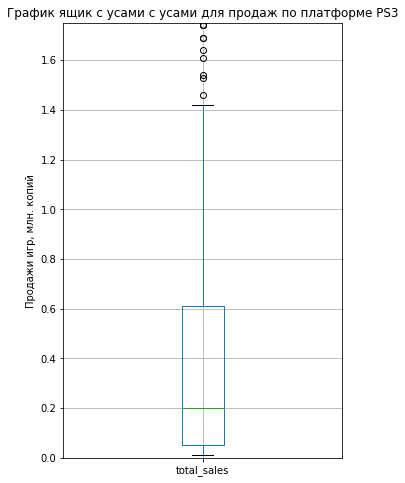

In [47]:
data.query('platform == "PS3"').boxplot('total_sales',
    grid=True, figsize=(5, 8))
plt.title("График ящик с усами с усами для продаж по платформе PS3")
#cтавим ограничение оси Y
plt.ylim(0, 1.75)
# Добавление меток осей
plt.ylabel('Продажи игр, млн. копий')

# Отображение графика
plt.show()

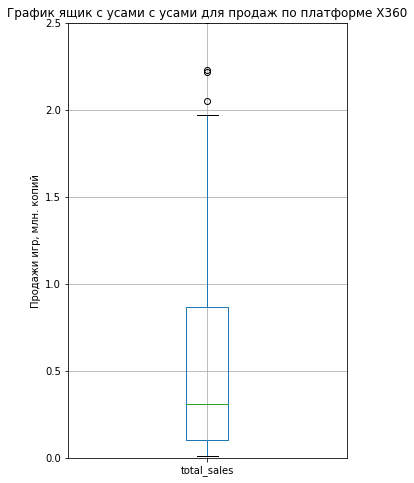

In [48]:
data.query('platform == "X360"').boxplot('total_sales',
    grid=True, figsize=(5, 8))
plt.title("График ящик с усами с усами для продаж по платформе X360")
#cтавим ограничение оси Y
plt.ylim(0, 2.5)
# Добавление меток осей
plt.ylabel('Продажи игр, млн. копий')

# Отображение графика
plt.show()

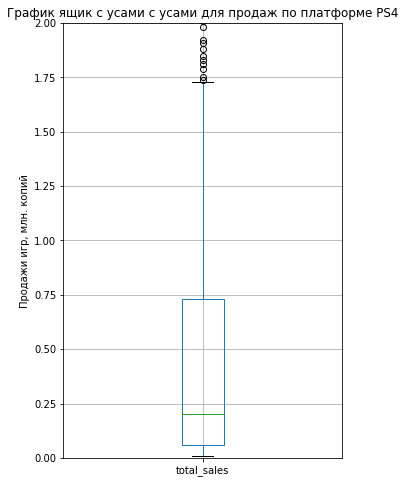

In [49]:
data.query('platform == "PS4"').boxplot('total_sales',
    grid=True, figsize=(5, 8))
plt.title("График ящик с усами с усами для продаж по платформе PS4")
#cтавим ограничение оси Y
plt.ylim(0, 2)
# Добавление меток осей
plt.ylabel('Продажи игр, млн. копий')

# Отображение графика
plt.show()

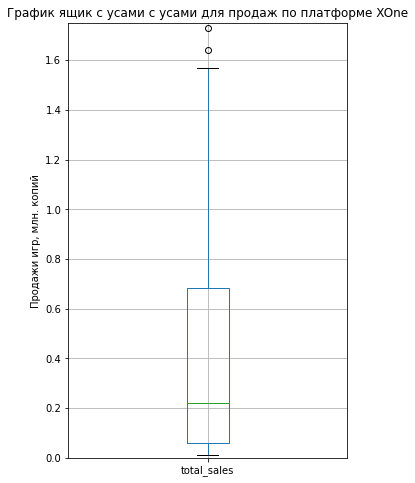

In [50]:
data.query('platform == "XOne"').boxplot('total_sales',
    grid=True, figsize=(5, 8))
plt.title("График ящик с усами с усами для продаж по платформе XOne")
#cтавим ограничение оси Y
plt.ylim(0, 1.75)
# Добавление меток осей
plt.ylabel('Продажи игр, млн. копий')

# Отображение графика
plt.show()

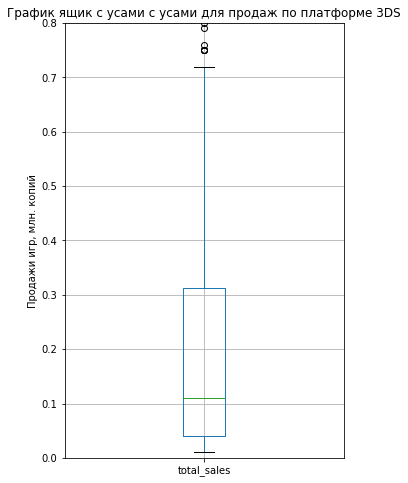

In [51]:
data.query('platform == "3DS"').boxplot('total_sales',
    grid=True, figsize=(5, 8))
plt.title("График ящик с усами с усами для продаж по платформе 3DS")
#cтавим ограничение оси Y
plt.ylim(0, 0.8)
# Добавление меток осей
plt.ylabel('Продажи игр, млн. копий')

# Отображение графика
plt.show()

**Вывод:**
1) Диаграммы "ящик с усами" для четырех популярных платформ PS3,X360, PS4, XOne выглядят очень похоже:
 - короткий ус, который почти упирается в 0 говорит о том, что было достаточное количество провальных игр с малым количеством продаж;
 - характерный для всех четырех межквартильный размах: 50 - 700 тыс. копий; 
 - Медианы также лежат очень близко: 200 - 300 тыс. копий. Медианны "молодых" платформ постепенно догоняют своих предшественников; 
 - длинные усы сверху говорят о том, что для этих платформ выходило достаточно большое количество хитов с продажами до 1,5 млн. копий;
 - также есть и статистические выбросы с продажами свыше 1,5 млн. копий.
 
2) Выделяется на фоне лидеров платформа 3DS:
 - медианна лежит около 100 тыс. копий
 - межквартильный размах 50 - 350 тыс. копий
 - верхний ус в районе 750 тыс. копий

#### Анализ влияния оценок критиков и пользователей на продажи игр для платформы PS4

Рассмотрим влияние оценок пользователей и критиков на итоговые продажи на примере абсолютного лидера 2015 года - PS4.

In [52]:
data_PS4 = data.query('platform == ["PS4"]')

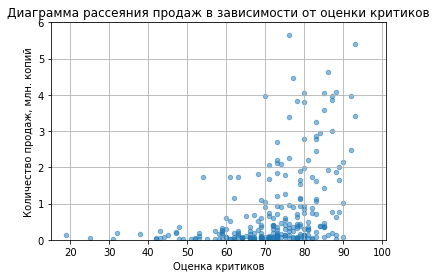

In [53]:
data_PS4.plot(x='critic_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж в зависимости от оценки критиков")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка критиков')
plt.ylabel('Количество продаж, млн. копий')

# Отображение графика
plt.show()

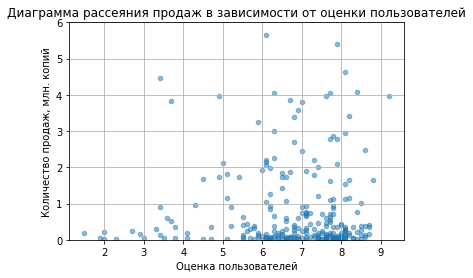

In [54]:
data_PS4.plot(x='user_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж в зависимости от оценки пользователей")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка пользователей')
plt.ylabel('Количество продаж, млн. копий')

# Отображение графика
plt.show()

In [55]:
data_PS4.corr()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,total_sales
year_of_release,1.000000,-0.248961,-0.208306,-0.060993,-0.234796,-0.021142,0.152447,-0.235032
na_sales,-0.248961,1.000000,0.785362,0.472981,0.944259,0.415008,-0.020933,0.928160
eu_sales,-0.208306,0.785362,1.000000,0.464563,0.944698,0.346720,-0.048925,0.958157
jp_sales,-0.060993,0.472981,0.464563,1.000000,0.496467,0.322358,0.171332,0.527129
other_sales,-0.234796,0.944259,0.944698,0.496467,1.000000,0.409191,-0.035639,0.998051
critic_score,-0.021142,0.415008,0.346720,0.322358,0.409191,1.000000,0.557654,0.406568
user_score,0.152447,-0.020933,-0.048925,0.171332,-0.035639,0.557654,1.000000,-0.031957
total_sales,-0.235032,0.928160,0.958157,0.527129,0.998051,0.406568,-0.031957,1.000000


Диаграмма рассеяния показывают очень слабое влияние оценок пользователей на продажи, уровень корелляции в -0,03 это подтверждает. Например: выявлены многочисленные значения оценок пользователей в районе 6-8 по десятибальной шкале, но с катастрофически маленьким показателем продаж.

Влияние оценок критиков на продажи заметно больше: вырисовывается прямая зависимость - чем выше оценки, тем лучше продажи. Уровень корелляции в 0,4 это подтверждает. 
С точки зрения логики можно сделать вывод, что произошла какая-то ошибка и все данные по платформме PS4 некорректные, потому и получились такие неоднозначные выводы. Проверим эту информацию на остальных лидерах продаж.

In [56]:
data_PS3 = data.query('platform == ["PS3"]')
data_XOne = data.query('platform == ["XOne"]')
data_X360 = data.query('platform == ["X360"]')
data_3DS = data.query('platform == ["3DS"]')

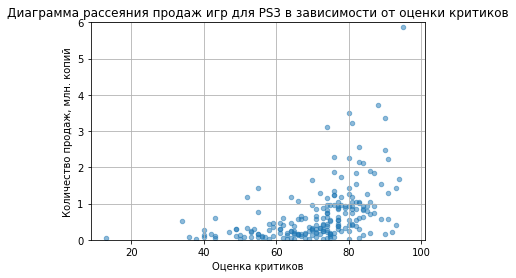

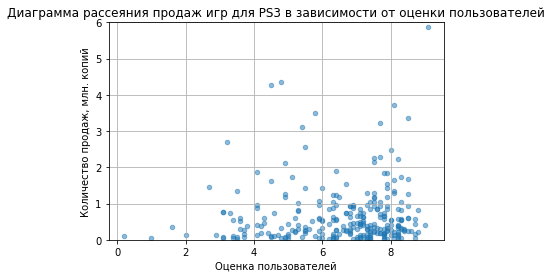

Уровень корреляции оценок критиков и продаж по платформе PS3 - 0.3341517575509856
Уровень корреляции оценок пользователей и продаж по платформе PS3 - -0.006205767686051523


In [57]:
data_PS3.plot(x='critic_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для PS3 в зависимости от оценки критиков")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка критиков')
plt.ylabel('Количество продаж, млн. копий')
# Отображение графика
plt.show()

data_PS3.plot(x='user_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для PS3 в зависимости от оценки пользователей")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка пользователей')
plt.ylabel('Количество продаж, млн. копий')

# Отображение графика
plt.show()
PS3_corr_сs = data.query('platform == ["PS3"]')['critic_score'].corr(data.query('platform == ["PS3"]')['total_sales'])
PS3_corr_us = data.query('platform == ["PS3"]')['user_score'].corr(data.query('platform == ["PS3"]')['total_sales'])
print(f'Уровень корреляции оценок критиков и продаж по платформе PS3 - {PS3_corr_сs}')
print(f'Уровень корреляции оценок пользователей и продаж по платформе PS3 - {PS3_corr_us}')

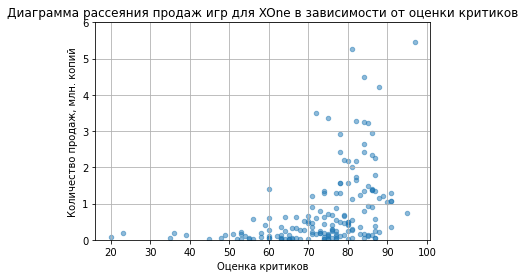

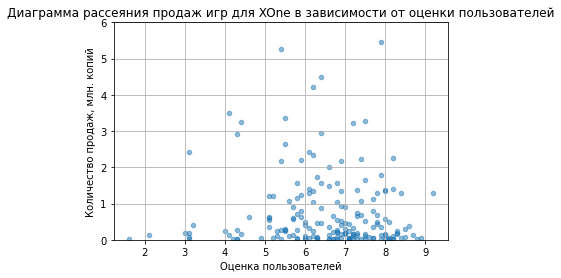

Уровень корреляции оценок критиков и продаж по платформе XOne - 0.4169983280084017
Уровень корреляции оценок пользователей и продаж по платформе XOne - -0.06892505328279414


In [58]:
data_XOne.plot(x='critic_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для XOne в зависимости от оценки критиков")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка критиков')
plt.ylabel('Количество продаж, млн. копий')
# Отображение графика
plt.show()

data_XOne.plot(x='user_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для XOne в зависимости от оценки пользователей")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка пользователей')
plt.ylabel('Количество продаж, млн. копий')

# Отображение графика
plt.show()
XOne_corr_сs = data.query('platform == ["XOne"]')['critic_score'].corr(data.query('platform == ["XOne"]')['total_sales'])
XOne_corr_us = data.query('platform == ["XOne"]')['user_score'].corr(data.query('platform == ["XOne"]')['total_sales'])
print(f'Уровень корреляции оценок критиков и продаж по платформе XOne - {XOne_corr_сs}')
print(f'Уровень корреляции оценок пользователей и продаж по платформе XOne - {XOne_corr_us}')

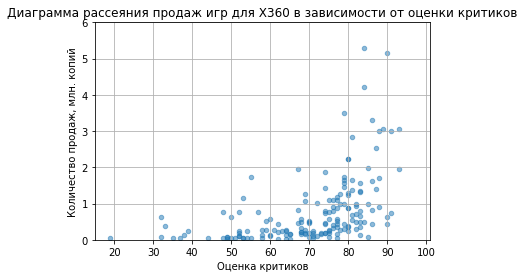

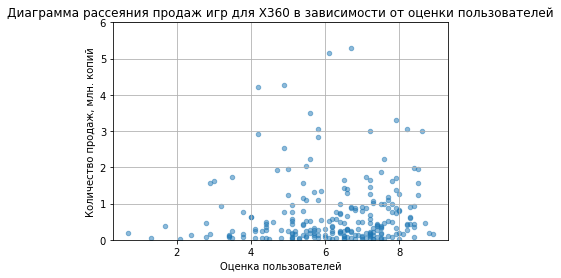

Уровень корреляции оценок критиков и продаж по платформе X360 - 0.3605734888507336
Уровень корреляции оценок пользователей и продаж по платформе X360 - 0.006163978646213326


In [59]:
data_X360.plot(x='critic_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для X360 в зависимости от оценки критиков")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка критиков')
plt.ylabel('Количество продаж, млн. копий')
# Отображение графика
plt.show()

data_X360.plot(x='user_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для X360 в зависимости от оценки пользователей")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка пользователей')
plt.ylabel('Количество продаж, млн. копий')

# Отображение графика
plt.show()
X360_corr_сs = data.query('platform == ["X360"]')['critic_score'].corr(data.query('platform == ["X360"]')['total_sales'])
X360_corr_us = data.query('platform == ["X360"]')['user_score'].corr(data.query('platform == ["X360"]')['total_sales'])
print(f'Уровень корреляции оценок критиков и продаж по платформе X360 - {X360_corr_сs}')
print(f'Уровень корреляции оценок пользователей и продаж по платформе X360 - {X360_corr_us}')


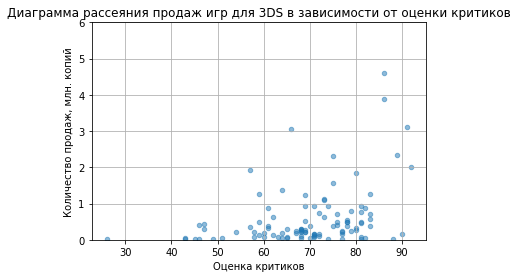

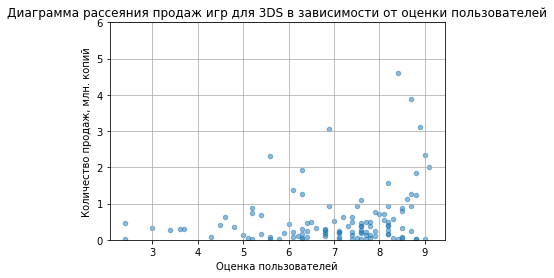

Уровень корреляции оценок критиков и продаж по платформе 3DS - 0.3208028695360785
Уровень корреляции оценок пользователей и продаж по платформе 3DS - 0.19758263411038599


In [60]:
data_3DS.plot(x='critic_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для 3DS в зависимости от оценки критиков")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка критиков')
plt.ylabel('Количество продаж, млн. копий')
# Отображение графика
plt.show()

data_3DS.plot(x='user_score', y='total_sales', grid= True, kind='scatter', alpha=0.5)
plt.title("Диаграмма рассеяния продаж игр для 3DS в зависимости от оценки пользователей")
#cтавим ограничение оси Y
plt.ylim(0, 6)
# Добавление меток осей
plt.xlabel('Оценка пользователей')
plt.ylabel('Количество продаж, млн. копий')

# Отображение графика
plt.show()
_3DS_corr_сs = data.query('platform == ["3DS"]')['critic_score'].corr(data.query('platform == ["3DS"]')['total_sales'])
_3DS_corr_us = data.query('platform == ["3DS"]')['user_score'].corr(data.query('platform == ["3DS"]')['total_sales'])
print(f'Уровень корреляции оценок критиков и продаж по платформе 3DS - {_3DS_corr_сs}')
print(f'Уровень корреляции оценок пользователей и продаж по платформе 3DS - {_3DS_corr_us}')

**Вывод:**
Информация подтверждается: влияние оценок пользователей на продажи ничтожно малое(уровень корелляции от -0,006 до 0,19). Оценки критиков имеют слабое влияние на уровень продаж(уровень корелляции от 0,32 до 0,42). 
При планировании оценки пользователей можно не учитывать совсем. Мнение критиков стоит учитывать, но далеко не в первую очередь.

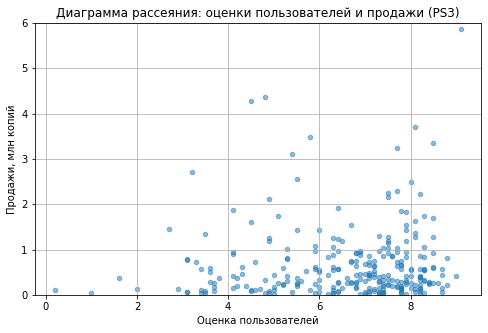

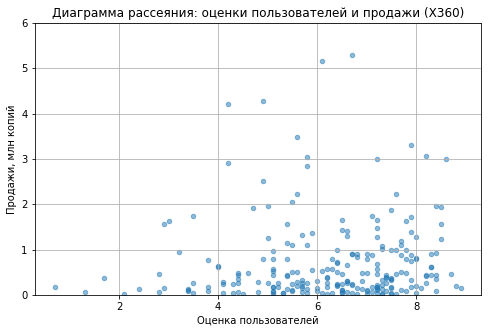

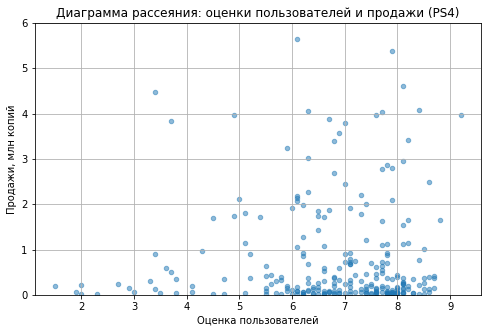

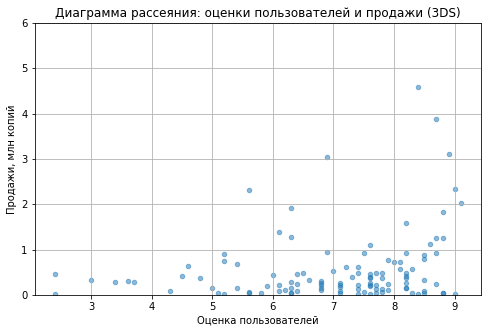

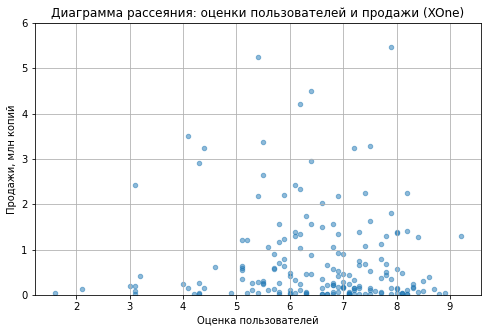

In [74]:
# Код ревьюера

platform_act = ["PS3", "X360", "PS4", "3DS", "XOne"]

for n in platform_act:
    platform_data = data.query('platform == @n')
    
    platform_data.plot(
        x='user_score',
        y='total_sales',
        kind='scatter',
        alpha=0.5,
        grid=True,
        figsize=(8, 5)
    )
    
    plt.title(f'Диаграмма рассеяния: оценки пользователей и продажи ({n})')
    plt.xlabel('Оценка пользователей')
    plt.ylabel('Продажи, млн копий')
    plt.ylim(0, 6)
    plt.show()

#### Анализ влияния жанра игр на продажи 

Рассмотрим влияние жанра игр на итоговые продажи в разрезе количества выпускаемых игр и числа проданных копий. Для начала посмотрим сколько всего игр каждого жанра осталось в датафрейме после фильтрации.

In [62]:
data_actual = data.query('platform == ["PS3","X360", "PS4", "3DS", "XOne"]')
data_actual['genre'].value_counts()

Action          657
Role-Playing    219
Sports          202
Shooter         180
Adventure       133
Misc            116
Fighting         83
Racing           82
Platform         53
Simulation       49
Strategy         30
Puzzle           15
Name: genre, dtype: int64

Сделаем сводную таблицу для построения диаграммы "ящик с усами", чтобы рассмотреть структуру данных.

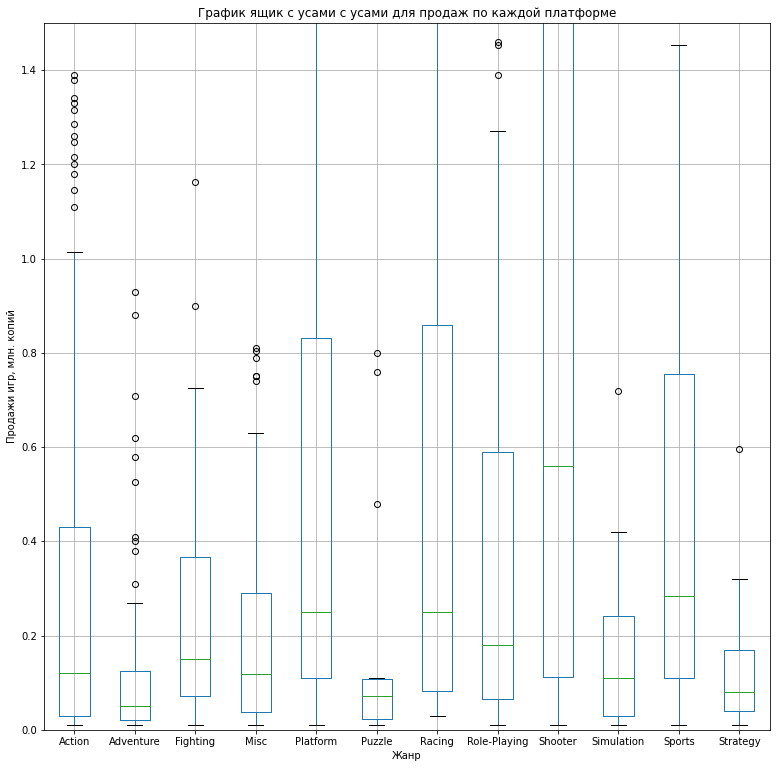

In [63]:
data_actual.pivot_table(
    index='name', columns='genre', values='total_sales').sort_values(by='name').boxplot(
    grid=True, 
    figsize=(13, 13))
plt.title("График ящик с усами с усами для продаж по каждой платформе")
#cтавим ограничение оси Y
plt.ylim(0, 1.5)
#Добавление меток осей
plt.xlabel('Жанр')
plt.ylabel('Продажи игр, млн. копий')


#Отображение графика
plt.show()

In [64]:
data_actual.pivot_table(index='name', columns='genre', values='total_sales').sort_values(by='name').describe()

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
count,392.000000,91.000000,51.000000,84.000000,34.000000,14.000000,41.000000,176.000000,88.000000,39.000000,89.000000,23.000000
mean,0.452380,0.152766,0.428154,0.277024,0.801245,0.188929,0.616931,0.674171,1.435057,0.575705,0.622603,0.128174
std,1.030738,0.290930,1.080525,0.631902,1.715102,0.276852,0.791738,1.641237,2.241697,1.695145,0.820814,0.136857
min,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.030000,0.010000,0.010000,0.010000,0.010000,0.010000
25%,0.030000,0.020000,0.072500,0.036875,0.110000,0.022500,0.083333,0.066250,0.111250,0.030000,0.110000,0.040000
50%,0.120000,0.050000,0.150000,0.117500,0.250000,0.072500,0.250000,0.180000,0.560000,0.110000,0.285000,0.080000
75%,0.431250,0.125833,0.366250,0.290000,0.831000,0.107500,0.860000,0.588750,1.741250,0.242500,0.755000,0.170000
max,13.852500,1.660000,7.550000,5.382500,9.900000,0.800000,3.230000,14.600000,13.735000,9.170000,4.025000,0.595000


**Вывод:**
1) Большое количество игр в рамках одного жанра не говорит о том, что игры этого жанра стабильно прибыльные - медиана для экшн игр лежит достаточно низко и большое количество статистических выбросов выше значения свыше 1 млн. проданных копий.

2) Самые низкоприбыльные жанры: приключения, пазлы и стратегии - медианное значение продаж ниже 200 тыс. копий.

3) Абсолютный лидер - шутеры. Медианное значнение продаж почти 560 тыс. проданных копий, что в два раза превышает второе значение (у спортивных игр), а среднее - 1,4 млн. Помимо стабильных продаж наблюдаются также и хиты с продажами свыше 13 млн. Также у этого жанра можно отметить самый большой межквартильный размах - 0,11-1,74.

4) На  втором, третьем и четвертом местах по прибыльности расположились спортивные игры, гонки и платформенные игры. Медианы в диапазоне 250-285 тыс.копий, средние значения - 617-801 тыс.копий. На графике у этих жанров все показатели очень похожи.

### Портрет пользователя каждого региона

#### Рейтинг популярных платформ 

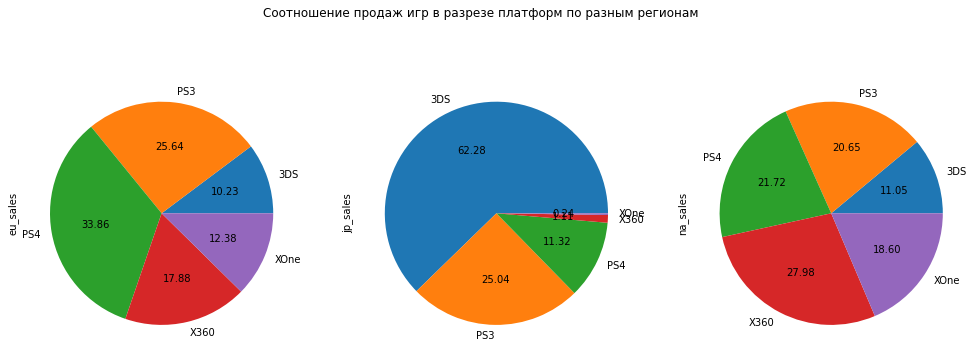

In [65]:
#фильтруем таблицу, группируем и строим график
data_actual.pivot_table(index='platform', values=['na_sales','eu_sales','jp_sales'], aggfunc='sum').plot(
    kind='pie',
    autopct='%.2f',
    subplots=True,
    grid=True, 
    figsize=(17, 6),
    legend=False,
    title='Соотношение продаж игр в разрезе платформ по разным регионам'
)
# Отображение графика
plt.show()

Соотношение продаж игр для разных платформ в Европе и Северной Америке достаточно похожи: 
 - старое поколение платформ (PlayStation 3 и XBox 360) занимает по 18-28%;
 - новое поколение (PlayStation 4 и XBox One) - по 12-33%;
 - платформа 3DS для обоих регионов одинаково уступает лидерам.
Однако существует одно существенное отличие - в Европе лучше продаются игры для PlayStation (совокупная доля - 59%), а в Северной Америке - для XBox (совокупная доля - 47%) и это надо учитывать при планировании рекламной кампании.
По отношению в предыдущим двум регионам сильно выделяется Япония. Очевидный лидер - 3DS  с долей рынка в 62%. На втором месте компания PlayStation с совокупной долей в 36%. Платформа XBox занимает меньше 2% рынка.

#### Рейтинг популярных жанров

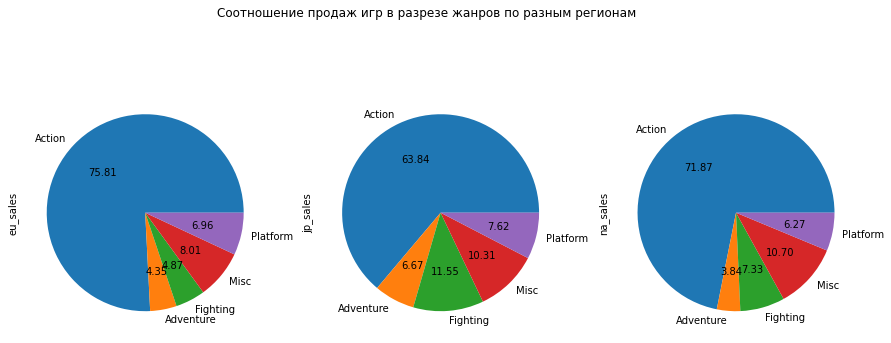

In [66]:
#фильтруем таблицу, группируем и строим график
data_actual.pivot_table(index='genre', values=['na_sales','eu_sales','jp_sales'], aggfunc='sum').head(5).plot(
    kind='pie',
    autopct='%.2f',
    subplots=True,
    grid=True, 
    figsize=(15, 6),
    title='Соотношение продаж игр в разрезе жанров по разным регионам',
    legend=False
)

# Отображение графика
plt.show()

Диаграмма соотношения долей продаж в разрезе по пяти самым популярным жанрам показывает, что картина для всех трех регионов практически идентичная с незначительными отличиями.
 - Однозначный лидер с долей 63-75% - жанр Action;
 - Пятое место занимает жанр Adventure с долей 4-7%;
 - Второе, третье и четвертое место делят Fighting, Misc и Platform. Доли в разных регионах отличаются не сильно - в диапазоне 5-12%.

#### Влияние рейтинга ESRB на продажи в отдельном регионе

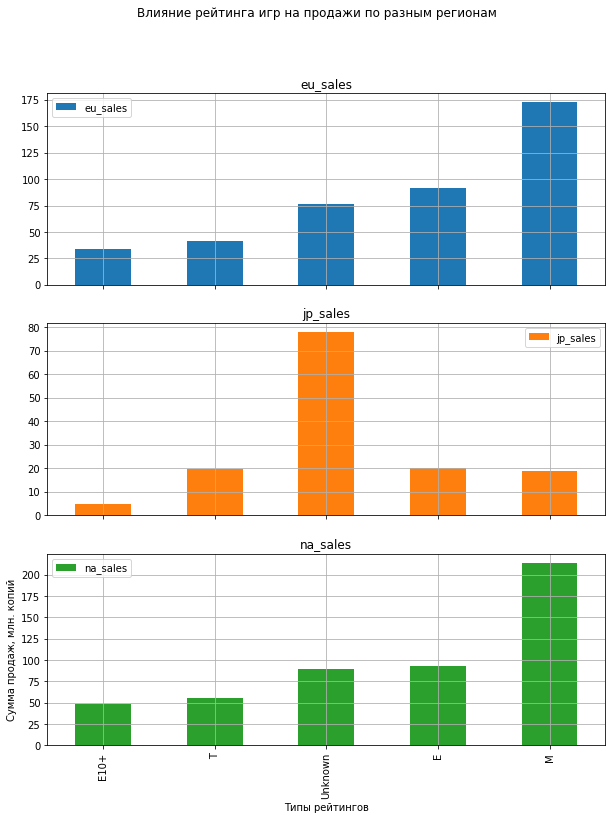

In [67]:
#фильтруем таблицу, группируем и строим график
data_actual.pivot_table(index='rating', values=['na_sales','eu_sales','jp_sales'], aggfunc='sum').sort_values(
    ['na_sales','eu_sales','jp_sales']).plot(
    kind='bar',
    subplots=True,
    grid=True, 
    figsize=(10,12),
    title='Влияние рейтинга игр на продажи по разным регионам'
)
plt.xlabel('Типы рейтингов')
plt.ylabel('Сумма продаж, млн. копий')
# Отображение графика
plt.show()

Из графиков выше можно сделать следующие выводы:

   - с точки зрения предпочтений игр разных категорий потребители из Северной Америки похожи на Европейских: абсолютными лидерами продаж являются игры категории М (для лиц 17 лет и старше).В два раза меньше продаж у игр рейтинга Е (для всех возрастных категорий). На третьем месте игры с неопределенным рейтингом.
   - В Японии не пользуются популярностью игры с рейтингом Е10+(для детей старше 10 лет), а вот продажи игр с остальными рейтингами распределены приблизительно равномерно. Выделяется столбец с пропущенными значениями. Это связано с тем, что данная система рейтингов мало используется в Японии.

**Промежуточный вывод:**

Для европейских пользователей можно выделить следующие особенности: предпочитают платформу Play Station, жанр экшн и рейтинг М.

Геймеры Северной Америки чаще играют на XBox. И также как и европейские предпочитают экшн игры рейтинга М.

В Японии не пользуется популярностью платформа 3DS и набирает популярность Play Station, предпочтения отдают играм жанра экшн с любым рейтингом кроме Е10+(для детей старше 10 лет).

### Проверка гипотез

#### Проверка гипотезы равенства средних значений пользовательских рейтингов платформ Xbox One и PC

Необходимо проверить равенство средних значений пользовательских рейтингов платформ Xbox One и PC.

Нулевая гипотеза: пользовательские рейтинги платформ Xbox One и PC равны.

Альтернативная гипотеза: пользовательские рейтинги платформ Xbox One и PC не равны.

In [68]:
XOne_score = data.query('platform == "XOne"')['user_score'].dropna().copy()
PC_score = data.query('platform == "PC"')['user_score'].dropna().copy()

In [69]:
alpha = 0.1#уровень статистической значимости
results = st.ttest_ind(XOne_score, PC_score)
print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 
print(f'Среднеарифметичесоке значение пользовательских рейтингов платформы Xbox One - {XOne_score.mean()}')
print(f'Среднеарифметичесоке значение пользовательских рейтингов платформы PC - {PC_score.mean()}')

p-значение: 0.5535080500643661
Не получилось отвергнуть нулевую гипотезу
Среднеарифметичесоке значение пользовательских рейтингов платформы Xbox One - 6.521428571428572
Среднеарифметичесоке значение пользовательских рейтингов платформы PC - 6.4286407766990274


Даже при самом высоком уровне статистической значимости в 10% не получилось опровергнуть гипотезу о том, что пользовательский рейтинг платформ Xbox One и PC равны.

#### Проверка гипотезы неравенства cредних пользовательских рейтингов двух жанров 

Нулевая гипотеза: пользовательские рейтинги жанра Action и Sports равны.

Альтернативная гипотеза: пользовательские рейтинги жанра Action и Sports не равны.

In [70]:
action_score = data.query('genre == "Action"')['user_score'].dropna().copy()
sports_score = data.query('genre == "Sports"')['user_score'].dropna().copy()

In [71]:
alpha = 0.05#уровень статистической значимости
results = st.ttest_ind(action_score, sports_score)
print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 
print(f'Среднеарифметичесоке значение пользовательских рейтингов жанра Action - {action_score.mean()}')
print(f'Среднеарифметичесоке значение пользовательских рейтингов жанра Sports - {sports_score.mean()}')

p-значение: 4.8045233804629176e-26
Отвергаем нулевую гипотезу
Среднеарифметичесоке значение пользовательских рейтингов жанра Action - 6.825047801147227
Среднеарифметичесоке значение пользовательских рейтингов жанра Sports - 5.455670103092784


Необходимо было проверить гипотезу о том, что cредние значения пользовательских рейтингов двух жанров экшн и спорт не равны. Для этого проводим тест "st.ttest_ind".

**Вывод:**

Первую гипотезу не получилось отвергнуть: пользовательские рейтинги жанра Action и Sports равны.

Во вотром случае подтвердили, что пользовательские рейтинги жанра Action и Sports не равны.

### Общий вывод

1) В представленном датафремейме 11 столбцов и 16715 строк. Пропуски данных обнаружены в 6 столбцах: название, год релиза, жанр, оценка критиков, оценка пользователей и рейтинг. Также в некоторых столбцах выявлены некорректные типы данных. 

2) Результаты предобработки данных:
 - Строки, где в столбцах ("название", "год выхода", "жанр") встречались пропуски удалили. На размерность датафрейма пости не повлияло.
 -  Пропуски в столбце "рейтинг" было принято решение не заполнять, т.к. логически это сделать невозможно.
 -  Пропуски в столбцах "оценка критиков", "оценка пользователей" частично заполнены. На основании среза исходного датафрейма без пропусков выявлена зависимость рассматриваемых столбцов со средним уровнем корелляции в 0,58.  Было принято решение провести заполнение пустых строк столбца "оценка критиков" на основе данных столбца "оценка пользователей" там где это было возможно, т.е. там где были данные хотя бы в одном из этих столбцов.
 -  Выявлено строковой значение "tbd" в оценках пользовалелей, что расшифровывается как "to be determined". Значения приравнены к пустым и либо удалены, либо заполнены.
 - Изменен тип данных в столбце  "оценка пользователей" на числовой.
 - Причины возниковения пропусков: малочисленные пропуски в столбцах  - скорее всего просто данные в исходном источнике отсутствовали. Более чем в половине данных отсутствовали значения в столбцах  "оценка критиков", "оценка пользователей", "рейтинг" и это были одни и те же строки. Выявить закономерность возникновения ошибок по году выхода и платформене не получилось. Вероятно, что это ошибка выгрузки данных. Необходимо отправить отчет об ошибке в соответствующий отдел.
 
3) Результаты исследовательского анализа:
 - До 1995 года выходило менее 200 игр в год. Дальше наблюдается резкий рост. Пиковое значение наблюдается в 2008 и 2009 годах. Далее идет такое же резкое снижение до 500 игр в год в 2016 году. Для целей настоящего исследования не все данные будут актуальны. Для анализа популярности и прибыльности платформ/жанров не все данные будут нужны, а некоторые могут и смазать результаты. С точки зрения количества выпускаемых игр примем в качестве актуальных данных диапазон 2001 - 2016 года, где выпускалось более 500 игр/год. 
 - Среди шести самых популярных платформ построили графики по продажам по годам. Из графиков видно что игры продавались для каждой отдельной платформы в среднем в диапазоне 10-12 лет. Информация полезна с точки зрения определения актуального периода для дальнейшего анализа - определим его в рамере половины среднего срока жизни платформы. Цифры по продажам устаревающих платформ не помогут в построении прогноза. Прогноз необходимо сделать на 2017 год, соотверственно актуальным временным диапазоном можно считать с 2012-2016 годы.
 - влияние оценок пользователей на продажи ничтожно малое(уровень корелляции от -0,006 до 0,19). Оценки критиков имеют слабое влияние на уровень продаж(уровень корелляции от 0,32 до 0,42). При планировании оценки пользователей можно не учитывать совсем. Мнение критиков стоит учитывать, но далеко не в первую очередь.
 - Самые низкоприбыльные жанры: приключения, пазлы и стратегии - медианное значение продаж ниже 200 тыс. копий. Абсолютный лидер - шутеры. Медианное значнение продаж почти 560 тыс. проданных копий, что в два раза превышает второе значение (у спортивных игр), а среднее - 1,4 млн. Помимо стабильных продаж наблюдаются также и хиты с продажами свыше 13 млн. Также у этого жанра можно отметить самый большой межквартильный размах - 0,11-1,74.
 
4) Портреты пользователей в разных регионах.
 - Для европейских пользователей можно выделить следующие особенности: предпочитают платформу Play Station, жанр экшн и рейтинг М.
 - Геймеры Северной Америки чаще играют на XBox. И также как и европейские предпочитают экшн игры рейтинга М.
 - В Японии не пользуются популярностью игры с рейтингом Е10+(для детей старше 10 лет), а вот продажи игр с остальными рейтингами распределены приблизительно равномерно. Выделяется столбец с пропущенными значениями. Это связано с тем, что данная система рейтингов мало используется в Японии.
 
5) Первую гипотезу не получилось отвергнуть: пользовательские рейтинги жанра Action и Sports равны. Во вотром случае подтвердили, что пользовательские рейтинги жанра Action и Sports не равны.